          Avg Char Len  Avg Word Count  Morph Complexity  Question Ratio (%)
Dataset                                                                     
Wellness     23.227092        6.499441          2.147340            2.613648
Chatbot      10.640373        3.218400          2.128330            9.636951
Subject      19.512606        5.478451          2.135648           21.454153


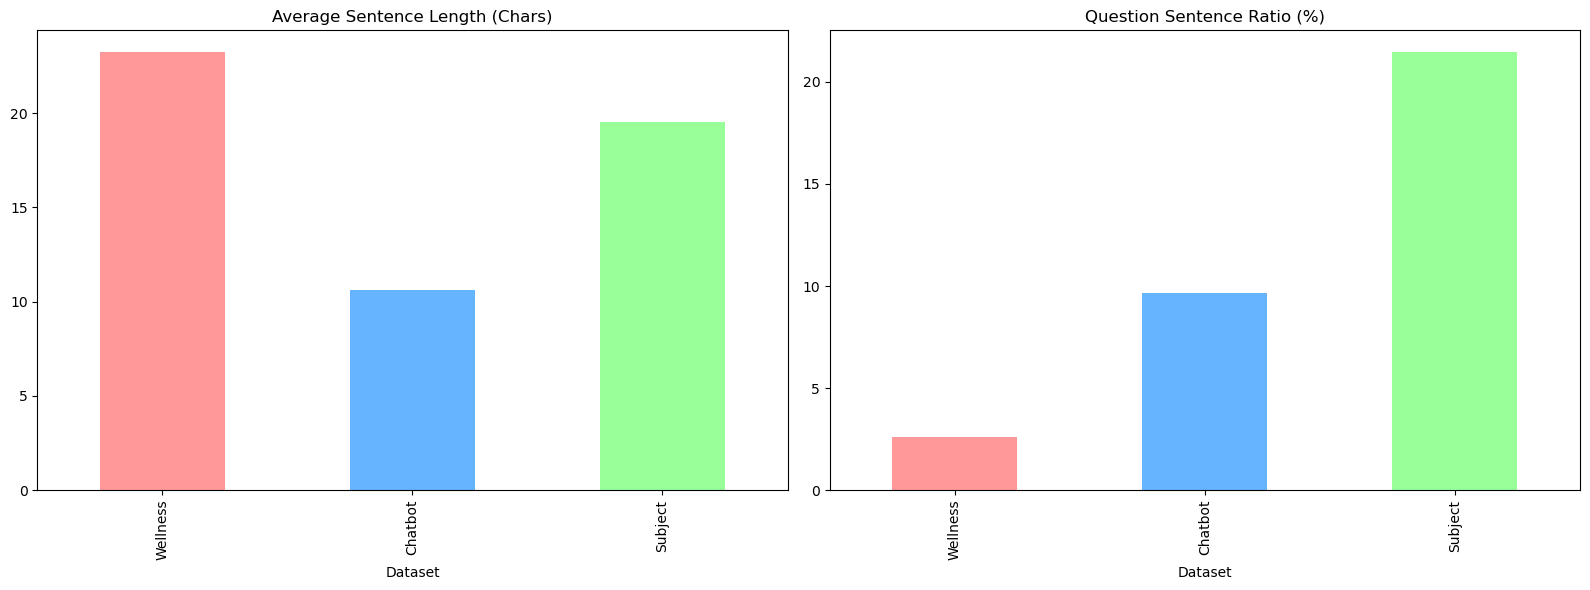

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()

def analyze_structure(df, name, column_name='utterance'):
    texts = df[column_name].dropna().astype(str).tolist()
    
    stats = []
    for sent in texts:
        # 가독성 기본 지표
        char_len = len(sent)          # 글자 수
        word_len = len(sent.split())  # 어절 수
        
        # 형태소 분석 및 복잡도
        tokens = kiwi.tokenize(sent)
        morph_count = len(tokens)     # 형태소 개수
        
        # 문장 유형 파악 (의문문 여부)
        is_question = 1 if '?' in sent or any(t.tag == 'EF' and t.form in ['니', '까', '죠', '가요'] for t in tokens) else 0
        
        stats.append({
            'char_len': char_len,
            'word_len': word_len,
            'morph_complexity': morph_count / word_len if word_len > 0 else 0, # 어절당 형태소 수
            'is_question': is_question
        })
    
    res_df = pd.DataFrame(stats)
    return {
        'Dataset': name,
        'Avg Char Len': res_df['char_len'].mean(),
        'Avg Word Count': res_df['word_len'].mean(),
        'Morph Complexity': res_df['morph_complexity'].mean(),
        'Question Ratio (%)': res_df['is_question'].mean() * 100
    }

# 2. 데이터셋별 실행
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

results = []
for name, file in files.items():
    df = pd.read_csv(file)
    results.append(analyze_structure(df, name))

# 3. 결과 정리 및 시각화
summary_df = pd.DataFrame(results).set_index('Dataset')
print(summary_df)

# 시각화: 문장 길이와 의문문 비율 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_df['Avg Char Len'].plot(kind='bar', ax=axes[0], color=['#ff9999','#66b3ff','#99ff99'], title='Average Sentence Length (Chars)')
summary_df['Question Ratio (%)'].plot(kind='bar', ax=axes[1], color=['#ff9999','#66b3ff','#99ff99'], title='Question Sentence Ratio (%)')

plt.tight_layout()
plt.show()